# Un coche autónomo hace algo raro. ¿Sabrías decir por qué?

Cuando el coche hacía algo inesperado, quien lo miraba acertaba el porqué **el 16,7 %** de las veces. Con las explicaciones del sistema encima: **36,9 %**. Veinte puntos más, y todavía falla dos de cada tres.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Kenny et al. (2026), *Explainable deep learning improves human mental models of self-driving cars*, **Nature**
**DOI:** [10.1038/s41586-026-10950-5](https://doi.org/10.1038/s41586-026-10950-5)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-09-02-ia-explicable-coche-autonomo/notebook.ipynb)

**Video:** [Ver en YouTube](https://youtube.com/shorts/noYpw9PRbxI)

## Qué midieron

Los coches autónomos deciden con redes neuronales profundas: cajas negras que conducen bien y no dicen por qué. El equipo construyó **CW-Net**, una capa que obliga a la parte que decide la maniobra (el planificador) a razonar con conceptos que un humano entiende — «hay un peatón», «el semáforo está en rojo» — y lo montó en un coche de pruebas real.

Aquí exploramos los dos estudios con humanos del paper, los únicos con datos públicos:

- **Estudio SAGAT** (99 personas) — congelar la escena y preguntar, el método clásico para medir si alguien está siguiendo lo que pasa: vieron repeticiones grabadas en carretera pública, y el equipo las pausaba para preguntarles qué veía el coche, por qué actuaba así y qué haría a continuación. Mitad con explicaciones de CW-Net, mitad con un texto de velocidad y dirección. **Asignación aleatoria.**
- **Estudio en simulador** (39 personas): 9 expertos en conducción autónoma y 30 no expertos, medidos antes y después de ver la explicación.

Dos cosas que conviene saber desde ya. El grupo de control **también recibía una explicación** (velocidad y dirección) para que la carga de leer fuera igual: lo que se compara no es «con o sin texto», es **qué tipo de texto**. Y ninguno de estos dos estudios ocurrió dentro del coche: son grabaciones en pantalla.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
UMBRAL_BONFERRONI = 0.05 / 6      # 6 comparaciones = 0,008333
D_MEDIO = 0.5                     # frontera de Cohen: efecto medio
D_GRANDE = 0.8                    # frontera de Cohen: efecto grande
FUENTE = 'Fuente: Kenny et al. (2026), Nature | Datos: repositorio CW-Net (GitHub)'
COLOR_DATOS = '#2563EB'           # azul CaM — grupo con explicaciones CW-Net
COLOR_ALERTA = '#DC2626'          # rojo — el resultado que va al revés
COLOR_REFERENCIA = '#D97706'      # ámbar — umbrales
COLOR_CONTEXTO = '#BBBBBB'        # gris — grupo de control / sin efecto
COLOR_SECUNDARIO = '#059669'      # verde — no expertos del simulador

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo editorial CaM (local si existe, si no lo baja del repo)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)


# Formato numérico español: coma decimal y signo menos tipográfico
def es(x, dec=1):
    return f'{x:.{dec}f}'.replace('.', ',').replace('-', '−')


# Código de color de las seis comparaciones:
#   azul  = pasa el umbral corregido por comparaciones múltiples
#   rojo  = el intervalo de confianza excluye el cero, pero no pasa la corrección
#   gris  = el intervalo cruza el cero (indistinguible de no haber diferencia)
def color_de(fila):
    if fila['bonferroni_significativo']:
        return COLOR_DATOS
    if fila['ic95_bajo'] * fila['ic95_alto'] > 0:
        return COLOR_ALERTA
    return COLOR_CONTEXTO


# Carga
precision = pd.read_csv('datos/sagat_precision_participante.csv')
efectos = pd.read_csv('datos/sagat_efectos.csv')
simulador = pd.read_csv('datos/simulador_modelo_mental.csv')

print('SAGAT (repeticiones de carretera pública)')
print('  personas:', precision['participante_id'].nunique(),
      '| filas:', len(precision), '(cada persona responde en las dos valencias)')
print(precision.groupby('grupo')['participante_id'].nunique().to_string())
print()
print('Simulador (antes / después de ver la explicación)')
print('  personas:', simulador['participante_id'].nunique(),
      '| observaciones:', len(simulador),
      '= personas x', simulador['escenario'].nunique(), 'escenarios')
print(simulador.groupby('grupo')['participante_id'].nunique().to_string())
print()
print('Umbral de significancia corregido (Bonferroni, 6 comparaciones):',
      es(UMBRAL_BONFERRONI, 6))

SAGAT (repeticiones de carretera pública)
  personas: 99 | filas: 198 (cada persona responde en las dos valencias)
grupo
control         48
experimental    51

Simulador (antes / después de ver la explicación)
  personas: 39 | observaciones: 117 = personas x 3 escenarios
grupo
expertos        9
no_expertos    30

Umbral de significancia corregido (Bonferroni, 6 comparaciones): 0,008333


## Aquí está.

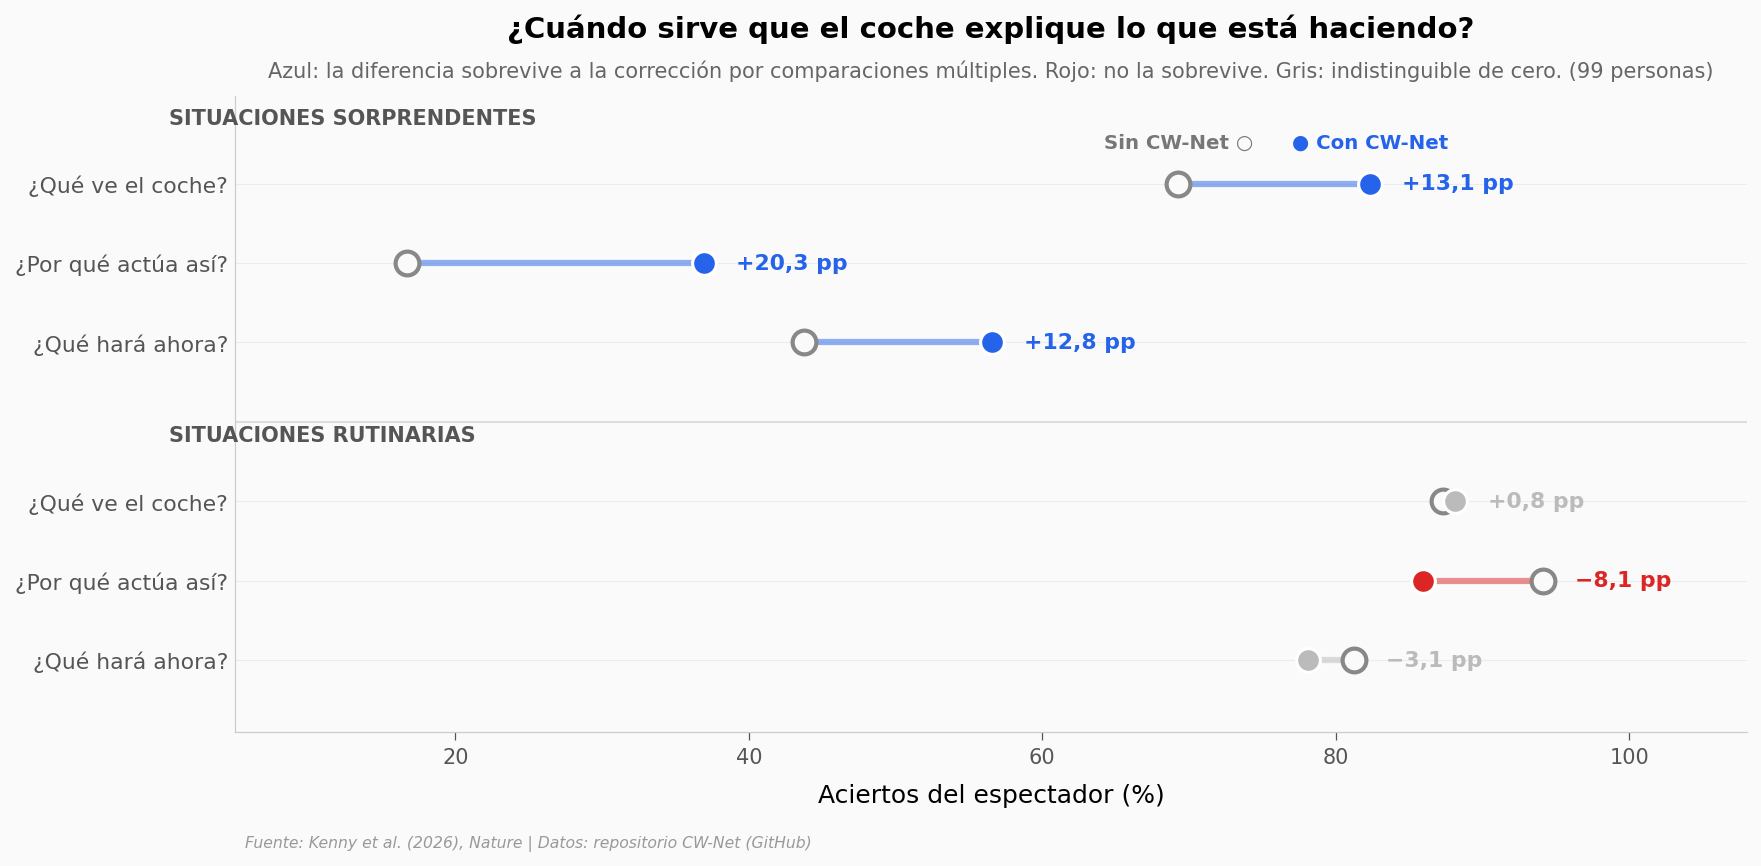

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

# Orden de arriba abajo: las tres dimensiones en situaciones sorprendentes,
# luego las mismas tres en situaciones rutinarias. Hueco entre bloques.
orden = [('sorprendente', 'percepcion'), ('sorprendente', 'comprension'),
         ('sorprendente', 'proyeccion'), ('rutinario', 'percepcion'),
         ('rutinario', 'comprension'), ('rutinario', 'proyeccion')]
etiquetas = {'percepcion': '¿Qué ve el coche?',
             'comprension': '¿Por qué actúa así?',
             'proyeccion': '¿Qué hará ahora?'}
posiciones = [6, 5, 4, 2, 1, 0]

for (val, dim), y in zip(orden, posiciones):
    fila = efectos[(efectos['valencia'] == val) & (efectos['dimension'] == dim)].iloc[0]
    c, x = fila['media_control'] * 100, fila['media_experimental'] * 100
    color = color_de(fila)
    ax.plot([c, x], [y, y], color=color, linewidth=3, alpha=0.5, zorder=3,
            solid_capstyle='round')
    # El control va hueco y el grupo con CW-Net relleno: así la forma dice
    # quién es quién aunque la línea vaya hacia la izquierda.
    ax.scatter([c], [y], facecolors='#FAFAFA', s=130, edgecolors='#888888',
               linewidths=2, zorder=5)
    ax.scatter([x], [y], color=color, s=130, edgecolors='white',
               linewidths=1.5, zorder=6)
    # Etiqueta de la diferencia, al lado del punto que quede más a la derecha
    dif = fila['diferencia_pp']
    signo = '+' if dif > 0 else '−'
    ax.text(max(c, x) + 2.2, y, f'{signo}{es(abs(dif))} pp',
            fontsize=10.5, fontweight='bold', color=color, va='center')

ax.set_yticks(posiciones)
ax.set_yticklabels([etiquetas[d] for _, d in orden], fontsize=10.5)
ax.set_xlabel('Aciertos del espectador (%)')
ax.set_xlim(5, 108)
ax.set_ylim(-0.9, 7.1)

# Rótulos de bloque a la izquierda del área de datos
ax.text(0.5, 6.75, 'SITUACIONES SORPRENDENTES', fontsize=10, fontweight='bold',
        color='#555555', ha='left')
ax.text(0.5, 2.75, 'SITUACIONES RUTINARIAS', fontsize=10, fontweight='bold',
        color='#555555', ha='left')
ax.axhline(y=3, color='#DDDDDD', linewidth=1)

# Inline labels en lugar de caja de leyenda (solo en la fila superior)
fila_top = efectos[(efectos['valencia'] == 'sorprendente') &
                   (efectos['dimension'] == 'percepcion')].iloc[0]
ax.text(fila_top['media_control'] * 100, 6.45, 'Sin CW-Net ○', fontsize=9.5,
        color='#777777', fontweight='bold', ha='center')
ax.text(fila_top['media_experimental'] * 100, 6.45, '● Con CW-Net', fontsize=9.5,
        color=COLOR_DATOS, fontweight='bold', ha='center')

ax.set_title('¿Cuándo sirve que el coche explique lo que está haciendo?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Azul: la diferencia sobrevive a la corrección por comparaciones '
        'múltiples. Rojo: no la sobrevive. Gris: indistinguible de cero. (99 personas)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/hero_sagat_dumbbell.png', dpi=200, bbox_inches='tight')
plt.show()

## El efecto vive entero en la mitad de arriba

Las explicaciones no sirven siempre: sirven **cuando el coche hace algo que no esperabas**. Ahí las tres preguntas mejoran a la vez, y la que más sube es la más difícil — entender el porqué gana 20,3 puntos porcentuales.

En lo rutinario, nada. Percepción se mueve 0,8 puntos y proyección baja 3,1: dos resultados indistinguibles del azar. Y hay uno que se mueve hacia abajo, la comprensión rutinaria, **8,1 puntos por debajo del control** — aunque se queda a las puertas del umbral corregido, así que tampoco es un resultado firme. Antes de leerlo como «las explicaciones estorban», mira de dónde parte: el grupo sin CW-Net acertaba el 94,1 %. Es un techo. Ahí no queda margen para mejorar y sí para tropezar.

Y un número que la gráfica esconde detrás del promedio: en situaciones sorprendentes, **16 de las 48 personas sin CW-Net no acertaron ni una sola** pregunta de comprensión. Con CW-Net fueron 2 de 51.

## ¿Y qué tan grande es «grande»?

Un valor de *p* dice si el efecto es distinguible del ruido, no si es importante. Para eso está la **d de Cohen**: cuántas desviaciones típicas separan a los dos grupos. Por convención, 0,5 es un efecto medio y 0,8 uno grande.

Con seis comparaciones sobre los mismos datos, la probabilidad de que alguna salga «significativa» por puro azar sube. La corrección de Bonferroni baja el listón exigido a 0,00833 — y una de las seis se queda justo afuera.

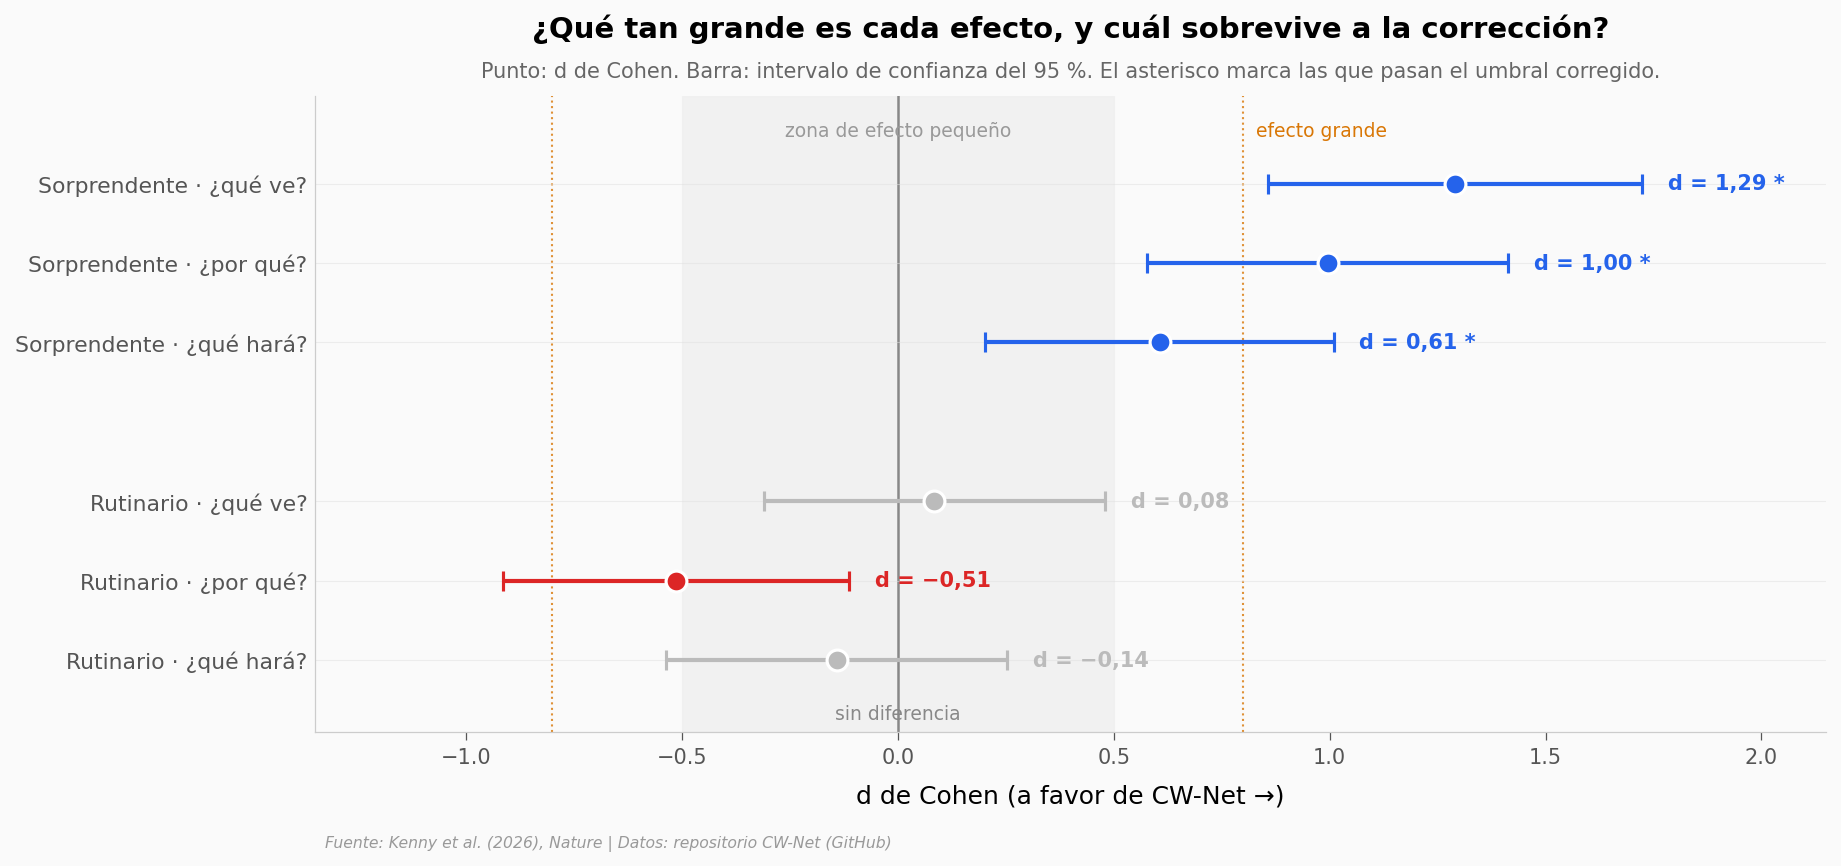

Umbral corregido: 0,008333
  sorprendente  percepcion   d =   1,290   p = 7.22e-09   PASA
  sorprendente  comprension  d =   0,996   p = 2.80e-06   PASA
  sorprendente  proyeccion   d =   0,606   p = 3.20e-03   PASA
  rutinario     percepcion   d =   0,085   p = 6.67e-01   no pasa
  rutinario     comprension  d =  −0,514   p = 1.12e-02   no pasa
  rutinario     proyeccion   d =  −0,142   p = 4.81e-01   no pasa


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

filas = []
for val in ['sorprendente', 'rutinario']:
    for dim in ['percepcion', 'comprension', 'proyeccion']:
        filas.append(efectos[(efectos['valencia'] == val) &
                             (efectos['dimension'] == dim)].iloc[0])
posiciones = [6, 5, 4, 2, 1, 0]

# Bandas de referencia de la d de Cohen
ax.axvspan(-D_MEDIO, D_MEDIO, color='#EEEEEE', alpha=0.7, zorder=0)
ax.axvline(x=0, color='#888888', linewidth=1.2, zorder=1)
for x in (-D_GRANDE, D_GRANDE):
    ax.axvline(x=x, color=COLOR_REFERENCIA, linewidth=1, linestyle=':',
               alpha=0.8, zorder=1)

for fila, y in zip(filas, posiciones):
    pasa = bool(fila['bonferroni_significativo'])
    color = color_de(fila)
    d = fila['d_cohen']
    err = [[d - fila['ic95_bajo']], [fila['ic95_alto'] - d]]
    ax.errorbar([d], [y], xerr=err, fmt='o', color=color, markersize=10,
                markeredgecolor='white', markeredgewidth=1.5,
                capsize=5, capthick=1.5, elinewidth=2, zorder=5)
    marca = ' *' if pasa else ''
    ax.text(fila['ic95_alto'] + 0.06, y, f'd = {es(d, 2)}{marca}', fontsize=10,
            fontweight='bold', color=color, va='center')

ax.set_yticks(posiciones)
ax.set_yticklabels(['Sorprendente · ¿qué ve?', 'Sorprendente · ¿por qué?',
                    'Sorprendente · ¿qué hará?', 'Rutinario · ¿qué ve?',
                    'Rutinario · ¿por qué?', 'Rutinario · ¿qué hará?'], fontsize=10.5)
ax.set_xlabel('d de Cohen (a favor de CW-Net →)')
ax.set_xlim(-1.35, 2.15)
ax.set_ylim(-0.9, 7.1)
ax.text(0, -0.75, 'sin diferencia', fontsize=9, color='#888888', ha='center')
ax.text(D_GRANDE + 0.03, 6.6, 'efecto grande', fontsize=9,
        color=COLOR_REFERENCIA, ha='left')
ax.text(0, 6.6, 'zona de efecto pequeño', fontsize=9, color='#999999', ha='center')

ax.set_title('¿Qué tan grande es cada efecto, y cuál sobrevive a la corrección?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Punto: d de Cohen. Barra: intervalo de confianza del 95 %. '
        'El asterisco marca las que pasan el umbral corregido.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/tamano_efecto.png', dpi=200, bbox_inches='tight')
plt.show()

print('Umbral corregido:', es(UMBRAL_BONFERRONI, 6))
for fila in filas:
    marca = 'PASA' if fila['bonferroni_significativo'] else 'no pasa'
    print(f"  {fila['valencia']:<13} {fila['dimension']:<12} "
          f"d = {es(fila['d_cohen'], 3):>7}   p = {fila['p_valor']:.2e}   {marca}")

## Lo que pasa en la cabeza no es lo que pasa en la respuesta

El segundo estudio pregunta otra cosa. En el simulador, cada persona veía una escena, decía qué tan segura estaba de entender al coche y qué creía que haría — y luego repetía el ejercicio con la explicación delante. Es una medida **antes/después dentro de la misma persona**: no hay grupo de control, así que mide el cambio, no lo que habría pasado sin explicación.

De las 117 observaciones (39 personas × 3 escenarios), el modelo mental **mejoró en 75, no se movió en 36 y empeoró en 6**. La predicción concreta es mucho más terca: mejoró en 29 y se quedó igual en 85.

Sentirse más capaz de anticipar al coche y acertar más son cosas distintas — y aquí se separan.

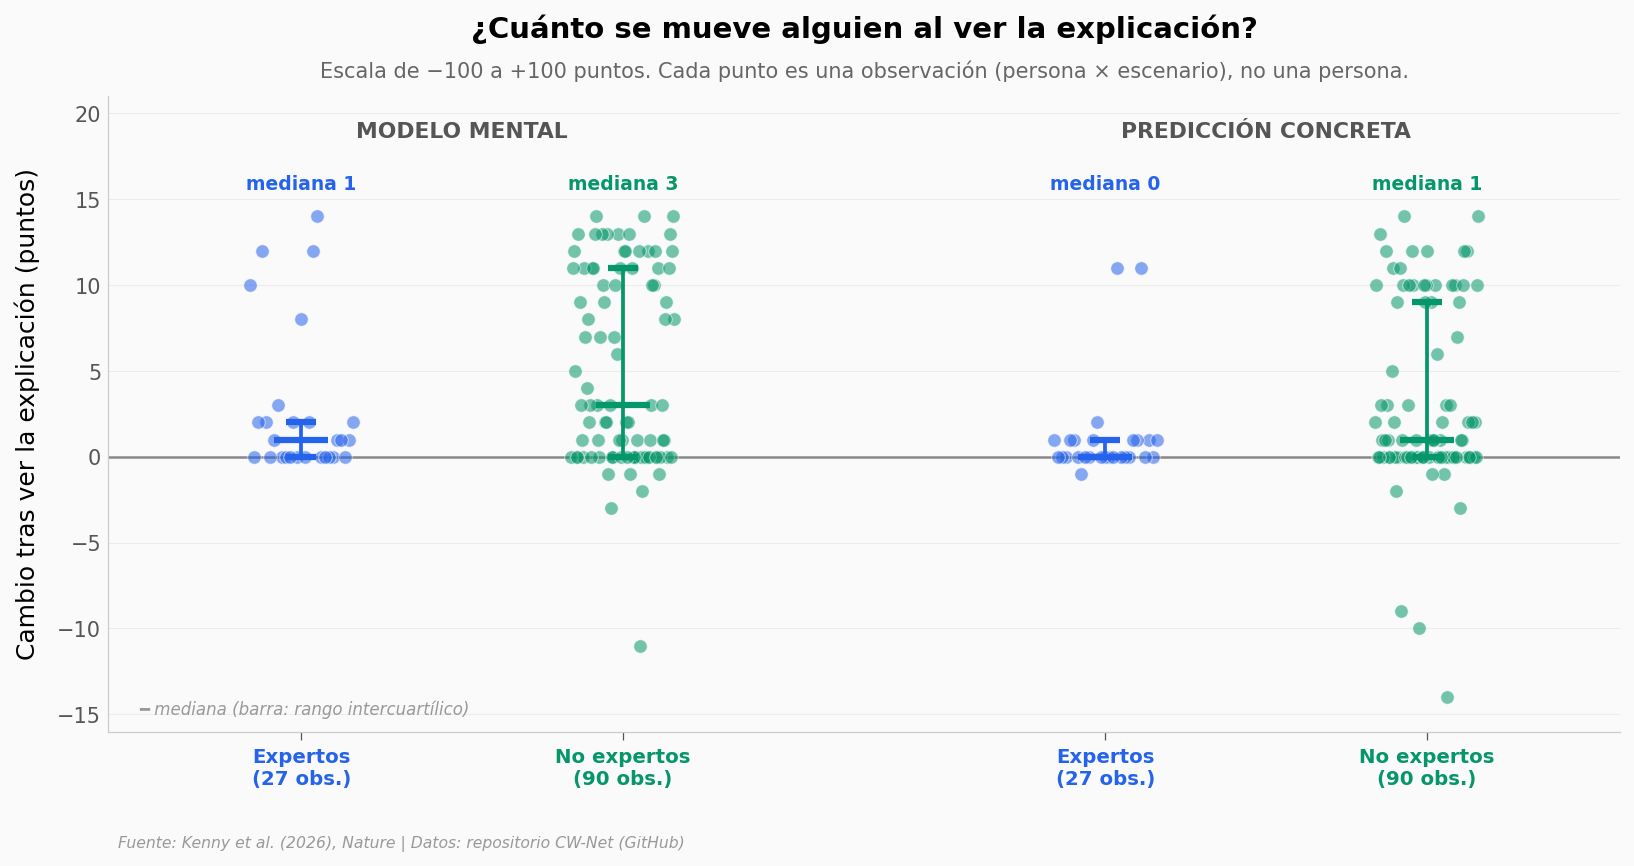

expertos     delta_modelo_mental    n =  27  mediana =  1,0  p = 3.03e-04
no_expertos  delta_modelo_mental    n =  90  mediana =  3,0  p = 5.89e-11
expertos     delta_prediccion       n =  27  mediana =  0,0  p = 2.55e-03
no_expertos  delta_prediccion       n =  90  mediana =  1,0  p = 1.46e-07


In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

grupos = [('expertos', 'delta_modelo_mental', 0, COLOR_DATOS),
          ('no_expertos', 'delta_modelo_mental', 1, COLOR_SECUNDARIO),
          ('expertos', 'delta_prediccion', 2.5, COLOR_DATOS),
          ('no_expertos', 'delta_prediccion', 3.5, COLOR_SECUNDARIO)]

np.random.seed(42)
ax.axhline(y=0, color='#888888', linewidth=1.2, zorder=2)

for grupo, columna, pos, color in grupos:
    vals = simulador[simulador['grupo'] == grupo][columna].values
    n = len(vals)
    x_strip = np.linspace(pos - 0.16, pos + 0.16, n)
    np.random.shuffle(x_strip)
    ax.scatter(x_strip, vals, color=color, s=42, alpha=0.55,
               edgecolors='white', linewidths=0.5, zorder=5)
    med = np.median(vals)
    q1, q3 = np.percentile(vals, [25, 75])
    ax.errorbar(pos, med, yerr=[[med - q1], [q3 - med]], fmt='_', color=color,
                markersize=26, markeredgewidth=3, capsize=7, capthick=1.5, zorder=6)
    ax.text(pos, 15.6, f'mediana {es(med, 0)}', fontsize=9, color=color,
            ha='center', fontweight='bold')

ax.set_xticks([0, 1, 2.5, 3.5])
ax.set_xticklabels(['Expertos\n(27 obs.)', 'No expertos\n(90 obs.)',
                    'Expertos\n(27 obs.)', 'No expertos\n(90 obs.)'],
                   fontsize=9.5, fontweight='bold')
for tick, (_, _, _, color) in zip(ax.get_xticklabels(), grupos):
    tick.set_color(color)
ax.set_ylabel('Cambio tras ver la explicación (puntos)')
ax.set_ylim(-16, 21)
ax.set_xlim(-0.6, 4.1)

ax.text(0.5, 18.6, 'MODELO MENTAL', fontsize=10.5, color='#555555', ha='center',
        fontweight='bold')
ax.text(3.0, 18.6, 'PREDICCIÓN CONCRETA', fontsize=10.5, color='#555555',
        ha='center', fontweight='bold')
ax.text(0.02, 0.02, '━ mediana (barra: rango intercuartílico)',
        transform=ax.transAxes, fontsize=8, color='#999999', ha='left',
        va='bottom', style='italic')

ax.set_title('¿Cuánto se mueve alguien al ver la explicación?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Escala de −100 a +100 puntos. Cada punto es una observación '
        '(persona × escenario), no una persona.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/simulador_cambio.png', dpi=200, bbox_inches='tight')
plt.show()

# Wilcoxon de rangos con signo: los datos son pareados (antes/después)
for grupo, columna, _, _ in grupos:
    vals = simulador[simulador['grupo'] == grupo][columna].values
    w = stats.wilcoxon(vals, alternative='greater', zero_method='wilcox')
    print(f'{grupo:<12} {columna:<22} n = {len(vals):>3}  '
          f'mediana = {es(np.median(vals), 1):>4}  p = {w.pvalue:.2e}')

## ¿Y qué tan raro es acertar tanto?

Los promedios de la primera gráfica esconden a las personas. La pregunta que cierra esto es más dura: el 82,4 % que promedió el grupo con CW-Net en situaciones sorprendentes, **¿lo alcanzó alguien sin las explicaciones?**

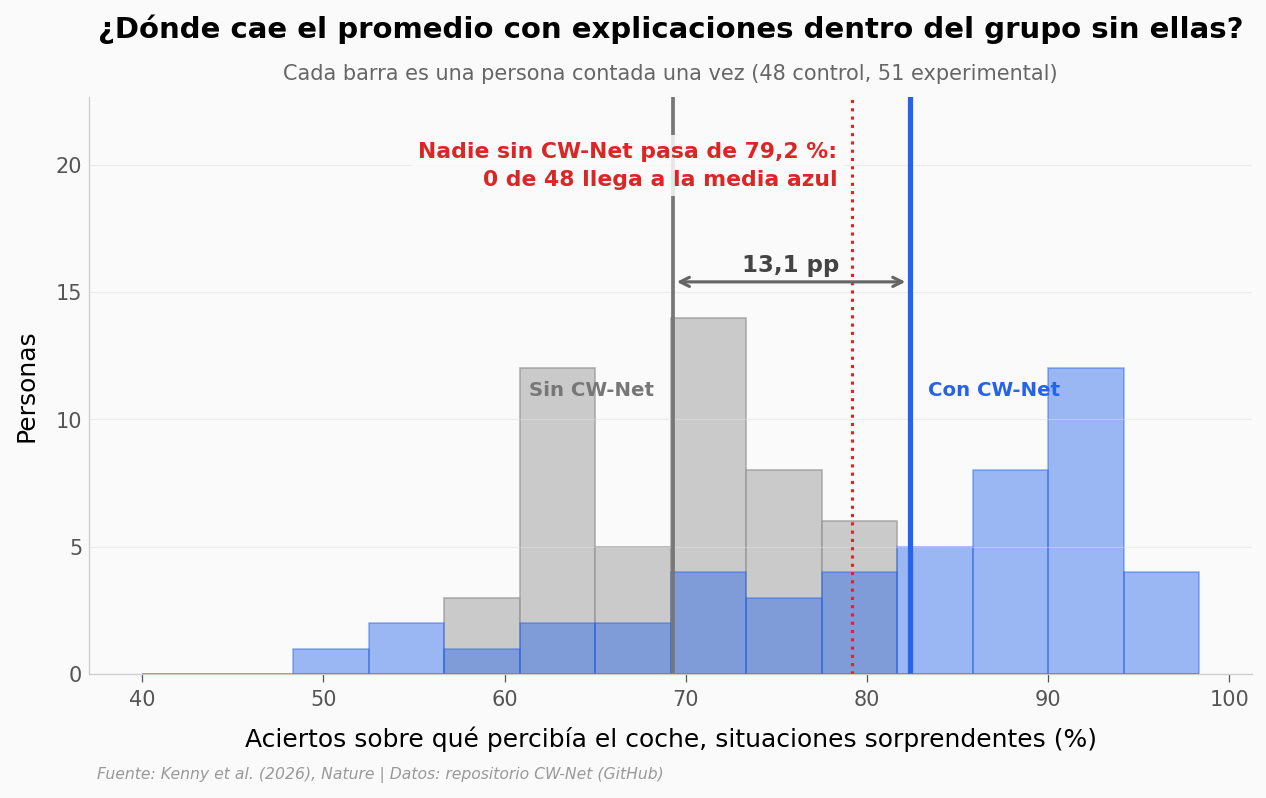

Máximo individual sin CW-Net: 79,17 %
Media del grupo con CW-Net:   82,35 %
Personas del control por encima de esa media: 0 de 48
Control:      mediana 70,8 %  RIC 62,5–75,0 %
Experimental: mediana 87,5 %  RIC 75,0–91,7 %


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

sorpr = precision[precision['valencia'] == 'sorprendente']
ctrl = sorpr[sorpr['grupo'] == 'control']['precision_percepcion'].values * 100
expe = sorpr[sorpr['grupo'] == 'experimental']['precision_percepcion'].values * 100
bins = np.arange(40, 102.5, 4.1667)   # el dato avanza de a 1/24 = 4,1667 puntos

n1, _, _ = ax.hist(ctrl, bins=bins, color=COLOR_CONTEXTO, alpha=0.75,
                   edgecolor='#999999', linewidth=0.8, label='Sin CW-Net')
n2, _, _ = ax.hist(expe, bins=bins, color=COLOR_DATOS, alpha=0.45,
                   edgecolor=COLOR_DATOS, linewidth=0.8, label='Con CW-Net')
alto = max(n1.max(), n2.max())
y_max = alto * 1.62
ax.set_ylim(0, y_max)

media_c, media_e = ctrl.mean(), expe.mean()
ax.axvline(x=media_c, color='#777777', linewidth=1.8)
ax.axvline(x=media_e, color=COLOR_DATOS, linewidth=2.5)
# Flecha de la diferencia justo encima de la barra más alta
y_flecha = alto + 1.4
ax.annotate('', xy=(media_e, y_flecha), xytext=(media_c, y_flecha),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((media_c + media_e) / 2, y_flecha + 0.4, f'{es(media_e - media_c)} pp',
        fontsize=11, fontweight='bold', color='#444444', ha='center')

# Tope individual del control: línea propia, sin flecha que cruce la gráfica
tope = ctrl.max()
ax.axvline(x=tope, color=COLOR_ALERTA, linewidth=1.5, linestyle=':')
ax.text(tope - 0.8, y_max * 0.88,
        f'Nadie sin CW-Net pasa de {es(tope)} %:\n'
        f'0 de 48 llega a la media azul',
        fontsize=10.5, fontweight='bold', color=COLOR_ALERTA, ha='right',
        va='center', linespacing=1.5,
        bbox=dict(facecolor='#FAFAFA', edgecolor='none', alpha=0.85, pad=3))

ax.text(media_c - 1, alto * 0.78, 'Sin CW-Net', fontsize=9.5, color='#777777',
        fontweight='bold', ha='right')
ax.text(media_e + 1, alto * 0.78, 'Con CW-Net', fontsize=9.5, color=COLOR_DATOS,
        fontweight='bold', ha='left')
ax.set_xlabel('Aciertos sobre qué percibía el coche, situaciones sorprendentes (%)')
ax.set_ylabel('Personas')

ax.set_title('¿Dónde cae el promedio con explicaciones dentro del grupo sin ellas?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada barra es una persona contada una vez (48 control, '
        '51 experimental)', transform=ax.transAxes, fontsize=10,
        color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalia_percepcion.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Máximo individual sin CW-Net: {es(ctrl.max(), 2)} %')
print(f'Media del grupo con CW-Net:   {es(media_e, 2)} %')
print(f'Personas del control por encima de esa media: {(ctrl >= media_e).sum()} de {len(ctrl)}')
print(f'Control:      mediana {es(np.median(ctrl), 1)} %  '
      f'RIC {es(np.percentile(ctrl, 25), 1)}–{es(np.percentile(ctrl, 75), 1)} %')
print(f'Experimental: mediana {es(np.median(expe), 1)} %  '
      f'RIC {es(np.percentile(expe, 25), 1)}–{es(np.percentile(expe, 75), 1)} %')

## Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| Con CW-Net se entiende mejor **qué percibe** el coche en situaciones sorprendentes | ✅ | +13,1 pp (69,3 % → 82,4 %), d = 1,29 (IC 95 %: 0,86–1,72), p = 7,2 × 10⁻⁹. Pasa la corrección por seis comparaciones. n = 99, asignación aleatoria |
| Con CW-Net se entiende mejor **por qué** actúa así en situaciones sorprendentes | ✅ | +20,3 pp (16,7 % → 36,9 %), d = 1,00 (IC 95 %: 0,58–1,41), p = 2,8 × 10⁻⁶. Es la mayor ganancia de las seis |
| Aun con CW-Net, la gente **sigue sin entender** al coche en lo sorprendente | ✅ | 36,9 % de aciertos: la respuesta más común sigue siendo la equivocada. La mediana individual es 33,3 % (RIC 16,7–50,0) |
| En situaciones rutinarias las explicaciones **no aportan** | ✅ | Percepción +0,8 pp (p = 0,67) y proyección −3,1 pp (p = 0,48): ninguna se distingue del azar |
| Las explicaciones **empeoran** la comprensión rutinaria | ⚠️ | −8,1 pp, d = −0,51, p = 0,0112 — no pasa el umbral corregido (0,00833). El control parte de 94,1 % (35 de 48 personas con puntaje perfecto): es un techo, no un margen |
| Tras ver la explicación, el modelo mental **mejora** | ✅ | 75 de 117 observaciones mejoran, 6 empeoran. Wilcoxon de rangos con signo: p = 0,0003 (expertos) y p = 5,9 × 10⁻¹¹ (no expertos) |
| Mejorar el modelo mental **no es** acertar más | ✅ | La predicción concreta solo cambia en 32 de 117 observaciones (29 mejoran, 3 empeoran). Mediana del cambio: 0 puntos en expertos, 1 en no expertos |
| Los no expertos **se mueven más** que los expertos | ⚠️ | Mediana 3 frente a 1 punto en modelo mental. No lo pusimos a prueba: el grupo experto son 9 personas y el paper no compara los dos grupos entre sí |
| CW-Net mejora el modelo mental **del conductor del coche real** | ⚠️ | Es el titular del abstract, pero descansa en el despliegue real: **1 conductor de seguridad y 3 situaciones**, en circuito privado y sin estadística. Todo lo que reprodujimos aquí son grabaciones en pantalla |
| CW-Net explica **sin sacrificar rendimiento** | ❌ | No verificable: los pesos del modelo del coche no son públicos y las tablas de rendimiento no vienen con datos |

> **Limitaciones:**
> - **Nada de esto pasó dentro del coche.** Los dos estudios con estadística usan repeticiones grabadas en pantalla. El despliegue real es una demostración de 3 situaciones con 1 conductor.
> - **El control también leía una explicación** (velocidad y dirección), para igualar la carga de lectura. El contraste es entre tipos de explicación, no entre tener y no tener.
> - **En el simulador, 27 y 90 son observaciones, no personas** (9 y 30 personas × 3 escenarios). Los pies de figura del paper cuentan observaciones; el repositorio lo advierte.
> - **El simulador no tiene grupo de control:** mide antes/después dentro de la misma persona, así que no separa el efecto de la explicación del efecto de ver la escena por segunda vez.
> - **La comprensión rutinaria parte del techo** (94,1 %). Una caída ahí no significa lo mismo que una caída desde la mitad de la escala.
> - **Conflicto de interés declarado y fuerte:** el estudio lo financia Motional (Hyundai + Aptiv), 7 de los 9 autores trabajan ahí, representantes de la financiadora participaron en la recolección de datos, el análisis y la decisión de publicar, y hay patentes pendientes sobre la arquitectura. Nada de esto invalida los datos — son públicos y los acabamos de recalcular —, pero va en la balanza.

## Ahora tú

1. **¿Y si el efecto viviera en una sola escena?** El estudio del simulador cruza 39 personas con 3 escenarios (`ASV`, `BIKE`, `CLOSE`). Prueba `simulador.groupby('escenario')['delta_modelo_mental'].median()` — si un escenario carga con todo el cambio, el resultado promedio dice menos de lo que parece.

2. **¿Cuánto aguanta la corrección de Bonferroni?** El umbral es 0,05 dividido entre el número de comparaciones. Cambia `UMBRAL_BONFERRONI` en la celda de configuración por `0.05 / 3` (como si solo miraras las situaciones sorprendentes) y vuelve a correr la gráfica de tamaños de efecto: ¿entra la comprensión rutinaria?

3. **¿La ganancia es de todos o de unos pocos?** En la celda de abajo cambia `DIMENSION` por `'proyeccion'`. Compara las medianas y los cuartiles además de las medias: un efecto que mueve a todo el grupo se ve distinto de uno que dispara a unos cuantos.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Recalcula desde cero cualquiera de las seis comparaciones del paper,
# partiendo de los datos por participante.
VALENCIA = 'sorprendente'     # 'sorprendente' o 'rutinario'
DIMENSION = 'comprension'     # 'percepcion', 'comprension' o 'proyeccion'


def comparar(valencia, dimension):
    sub = precision[precision['valencia'] == valencia]
    a = sub[sub['grupo'] == 'experimental'][f'precision_{dimension}'].values * 100
    b = sub[sub['grupo'] == 'control'][f'precision_{dimension}'].values * 100
    # t de Welch: no asume varianzas iguales (los grupos son independientes)
    t, p = stats.ttest_ind(a, b, equal_var=False)
    # d de Cohen agrupada
    sd = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) /
                 (len(a) + len(b) - 2))
    d = (a.mean() - b.mean()) / sd
    ee = np.sqrt((len(a) + len(b)) / (len(a) * len(b)) +
                 d ** 2 / (2 * (len(a) + len(b))))
    return a, b, t, p, d, (d - 1.96 * ee, d + 1.96 * ee)


a, b, t, p, d, ic = comparar(VALENCIA, DIMENSION)
print(f'{VALENCIA} · {DIMENSION}')
print(f'  Con CW-Net: media {es(a.mean(), 2)} %  mediana {es(np.median(a), 1)} %  '
      f'RIC {es(np.percentile(a, 25), 1)}–{es(np.percentile(a, 75), 1)} %  n = {len(a)}')
print(f'  Sin CW-Net: media {es(b.mean(), 2)} %  mediana {es(np.median(b), 1)} %  '
      f'RIC {es(np.percentile(b, 25), 1)}–{es(np.percentile(b, 75), 1)} %  n = {len(b)}')
print(f'  Diferencia: {es(a.mean() - b.mean(), 2)} pp')
print(f'  d de Cohen: {es(d, 3)}  (IC 95 %: {es(ic[0], 3)} a {es(ic[1], 3)})')
print(f'  t de Welch: {es(t, 3)}   p = {p:.3e}   '
      f"{'pasa' if p < UMBRAL_BONFERRONI else 'NO pasa'} el umbral corregido")
print()
print('Comprobación contra la tabla del paper:')
print(efectos[(efectos['valencia'] == VALENCIA) &
              (efectos['dimension'] == DIMENSION)]
      [['diferencia_pp', 'd_cohen', 'ic95_bajo', 'ic95_alto', 'p_valor']].to_string(index=False))

sorprendente · comprension
  Con CW-Net: media 36,93 %  mediana 33,3 %  RIC 16,7–50,0 %  n = 51
  Sin CW-Net: media 16,67 %  mediana 16,7 %  RIC 0,0–16,7 %  n = 48
  Diferencia: 20,26 pp
  d de Cohen: 0,996  (IC 95 %: 0,578 a 1,413)
  t de Welch: 5,006   p = 2.798e-06   pasa el umbral corregido

Comprobación contra la tabla del paper:
 diferencia_pp  d_cohen  ic95_bajo  ic95_alto  p_valor
       20.2614   0.9956     0.5778     1.4134 0.000003


## Fuentes

**Paper**: [Explainable deep learning improves human mental models of self-driving cars](https://doi.org/10.1038/s41586-026-10950-5)  
*Nature, 2026-09-02*

**Dataset canónico**: [CW-Net Reproducibility Capsule — Autonomous Driving (datos anonimizados de los estudios SAGAT y de simulador)](https://github.com/EoinKenny/CW-Net-Autonomous-Driving)  
*GitHub — datos anonimizados de los estudios SAGAT y de simulador, con el preprocesamiento oficial del repositorio*

*19 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook de [Ciencia a Mordiscos](https://cienciaamordiscos.com) — el código y los datos de este análisis están en el [repositorio de El Lab](https://github.com/Ciencia-a-Mordiscos/lab).*